# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respaldar conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiadas** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Hallazgos**
 - El dataset no tiene valores nulos.
 - La columna `date` tiene tipo de dato object, en caso de ser necesario para el análisis, se debe cambiar a tipo de dato datetime con pd.to_datetime
 - Todas las columnas tienen 40.000 registros no nulos.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
print(f"Usuarios únicos: {df['user_id'].nunique()}")

Usuarios únicos: 40000


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
variables_categoricas= df[['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']]
print("\nConteo de categorías:\n")
print(f"Conteo de landing: \n{df['landing'].value_counts()}\n")
print(f"Conteo de region: \n{df['region'].value_counts()}\n")
print(f"Conteo de dispositivo: \n{df['dispositivo'].value_counts()}\n")
print(f"Conteo de traffic_source: \n{df['traffic_source'].value_counts()}\n")
print(f"Conteo de user_type: \n{df['user_type'].value_counts()}\n")
print(f"Describe categorías: \n{variables_categoricas.describe()}")


Conteo de categorías:

Conteo de landing: 
B    20018
A    19982
Name: landing, dtype: int64

Conteo de region: 
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Conteo de dispositivo: 
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Conteo de traffic_source: 
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Conteo de user_type: 
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

Describe categorías: 
       landing region dispositivo traffic_source user_type
count    40000  40000       40000          40000     40000
unique       2      5           2              4         2
top          B  Norte      Mobile        Organic     Nuevo
freq     20018  11166       24829          17987     26033


In [ ]:
#Categorías por proporción
print("\nProporción por categorías:\n")
print(f"Proporción de landing: \n{df['landing'].value_counts(normalize=True)*100}\n")
print(f"Proporción de region: \n{df['region'].value_counts(normalize=True)*100}\n")
print(f"Proporción de dispositivo: \n{df['dispositivo'].value_counts(normalize=True)*100}\n")
print(f"Proporción de traffic_source: \n{df['traffic_source'].value_counts(normalize=True)*100}\n")
print(f"Proporción de user_type: \n{df['user_type'].value_counts(normalize=True)*100}\n")


Proporción por categorías:

Proporción de landing: 
B    50.045
A    49.955
Name: landing, dtype: float64

Proporción de region: 
Norte        27.9150
Centro       24.0325
Sur          20.0975
Occidente    15.9950
Oriente      11.9600
Name: region, dtype: float64

Proporción de dispositivo: 
Mobile     62.0725
Desktop    37.9275
Name: dispositivo, dtype: float64

Proporción de traffic_source: 
Organic     44.9675
Ads         29.8375
Email       15.3075
Referral     9.8875
Name: traffic_source, dtype: float64

Proporción de user_type: 
Nuevo         65.0825
Recurrente    34.9175
Name: user_type, dtype: float64



✍️ **Hallazgos**
- No se observan categorías con nombres incorrectos, ni valores erróneos.
- Los valores de Landing A y B están balanceados, esto evita sesgos en el análisis.
  
**Las categorías dominantes son:**
- Región Norte con 11.166 registros y proporción 27.91
- Dispositivo Mobile con 24.829 registros y proporción 62.07
- Traffic source Organic con 17.987 registros y proporción 44.97
- User_type nuevo con 26.033 registros y proporción 65.08

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Calcular promedio de gastos por grupo
print(f"Promedio de gasto A:\n {gasto_A.mean()}\n")
print(f"Promedio de gasto B:\n {gasto_B.mean()}\n")

# Verificar cantidad de datos que tiene cada grupo
print("Cantidad de datos de cada grupo")
len(gasto_A), len(gasto_B)

Promedio de gasto A:
 61.0865724522293

Promedio de gasto B:
 68.74536005009392

Cantidad de datos de cada grupo


(2512, 3194)

La versión B de la página tuvo mayor gasto promedio con 68.74; la versión A tuvo 61.08

### Prueba t de student

**Hipótesis:**
**Hipótesis nula (H₀):**
- El gasto promedio es igual en ambas versiones de las página.
  
**Hipótesis alternativa (H₁):**
- El gasto promedio es diferente entre las versiones de la página.

In [ ]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

alpha= 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p es menor a 0.05 se rechaza la hipótesis nula, es decir el gasto promedio es diferente en las 2 versiones de las páginas.

**Interpretación de negocio:**  

- Hay evidencia de que la diferencia no es fruto del azar, el resultado es estadísticamente significativo.
- Con base en la prueba t aplicada a los 2 grupos de usuarios, se encontró evidencia estadística de una diferencia en el gasto promedio entre las versiones de las páginas A y B.
- En promedio, los usuarios que convirtieron en la página B gastaron más que los de la página A.
- Este resultado se basa en 2 grupos de usuarios que realizaron compras y no evalúa si la diferencia observada es suficiente para justificar un cambio desde una perspectiva de negocio.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba z

**Hipótesis:**

**Hipótesis nula (H₀):**
- La tasa de conversión es igual en ambas versiones de la página.
  
**Hipótesis alternativa (H₁):**
- La tasa de conversión es diferente en las 2 versiones de la página.

In [ ]:
# Número de usuarios convertidos por página
conversiones= df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales= df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Organizar datos en listas
exitos= [conversiones['A'], conversiones['B']]
observaciones= [totales['A'], totales['B']]

In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

alpha= 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [ ]:
# Calcular tasas de conversión
# Obtener tasa o porcentaje de éxito
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%)


### 📝 Conclusión e interpretación

**Decisión:**  
- Se rechaza la hipótesis nula, hay evidencia de una diferencia entre las tasas de conversión de la página A y B.

**Interpretación de negocio:**
- Con base en un z-test para proporciones, se encontró evidencia estadística de que la tasa de conversión difiere entre la página A y la página B.
- La tasa de conversión de la página A es 12.57%
- La tasa de conversión de la página B es 15.96%
- La tasa de conversión de la página B es mayor 3.38% que la página A.
- Este resultado sugiere que la página B tiene mayor conversión que la página A.

**Limitaciones:**
- La conversión se mide como evento binario (sí / no).
- El análisis asume observaciones independientes.
- No se evalúa aquí si la diferencia justifica un cambio de negocio.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una relación entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Si existe una relación entre la fuente de tráfico y la conversión.

In [ ]:
# Usuarios que compraron
print(df['converted'].value_counts())
print("5706 usuarios compraron")
print()

# Tabla de contingencia
tabla_traffic= pd.crosstab(df['traffic_source'], df['converted'])
print('Tabla de contingencia')
print(tabla_traffic)

0    34294
1     5706
Name: converted, dtype: int64
5706 usuarios compraron

Tabla de contingencia
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_traffic)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")



Estadístico chi-cuadrado: 8.662
Valor P: 0.034


In [ ]:
# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Se rechaza la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

# Tabla de contingencia normalizada
tabla_normalizada_traffic= pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100
print('\nProporción de conversión por traffic source')
print(tabla_normalizada_traffic)

Se rechaza la hipótesis nula: hay evidencia de asociación entre las variables.

Proporción de conversión por traffic source
converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula:
- Hay evidencia de asociación entre las 2 variables. Valor p bajo (0.034)
- Existe una asociación estadísticamente significativa entre el tipo de tráfico y la conversión.

**Interpretación de negocio:**  

- La mayor tasa se visualiza en Email con 918 conversiones y proporción de 14.99% Sugiere ser la fuente más efectiva para conversión.
- Ads 1759 conversiones (14.73%)
- Referral 549 conversiones (13.88%)
- Organic 2480 conversiones (13.78%)
- Las diferencias, aunque estadísticamente significativas, son relativamente pequeñas (1% a 2%)
- Se podría segmentar la inversión de marketing por tipo de tráfico, dado que se evidencia diferencias significativas.
- Enfocar esfuerzos en optimizar el email marketing (canal mas efectivo).

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una relación entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Si existe una relación entre el tipo de usuario y la conversión.

In [ ]:
# Tabla de contingencia
tabla_user= pd.crosstab(df['user_type'], df['converted'])
print('Tabla de contingencia user_type')
print(tabla_user)

Tabla de contingencia user_type
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_user)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")


Estadístico chi-cuadrado: 0.513
Valor P: 0.474


In [ ]:
# Interpretar resultados
if p_value < alpha:
    print("Se rechaza la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

# Tabla de contingencia normalizada
tabla_normalizada_user= pd.crosstab(df['user_type'], df['converted'], normalize='index')*100
print('\nProporción de conversión por user_type')
print(tabla_normalizada_user)

No se rechaza la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.

Proporción de conversión por user_type
converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


### 📝 Conclusión e interpretación

**Decisión:**  
- Valor p alto (0.474): No se rechaza la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.
- Valor p muy por encima de 0.05, la evidencia es clara: no hay diferencia significativa.
- El chi-cuadrado = 0.513 es muy bajo, esto sugiere que las diferencias observadas son probablemente por azar.

**Interpretación de negocio:**  
- El tipo de usuario nuevo convierte 14.35%
- El tipo de usuario recurrente convierte 14.09%
- Las proporciones de conversión son muy similares.
- El tipo de usuario nuevo convierte ligeramente un poco más que el recurrente (0.26%), la diferencia es mínima en términos de negocio.
- Esto sugiere que no se debería segmentar la inversión según el tipo de usuario.
- Una sola estrategia de marketing sirve para ambos segmentos.
- Eficiencia de recursos: No se considera necesario crear campañas separadas por tipo de usuario.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

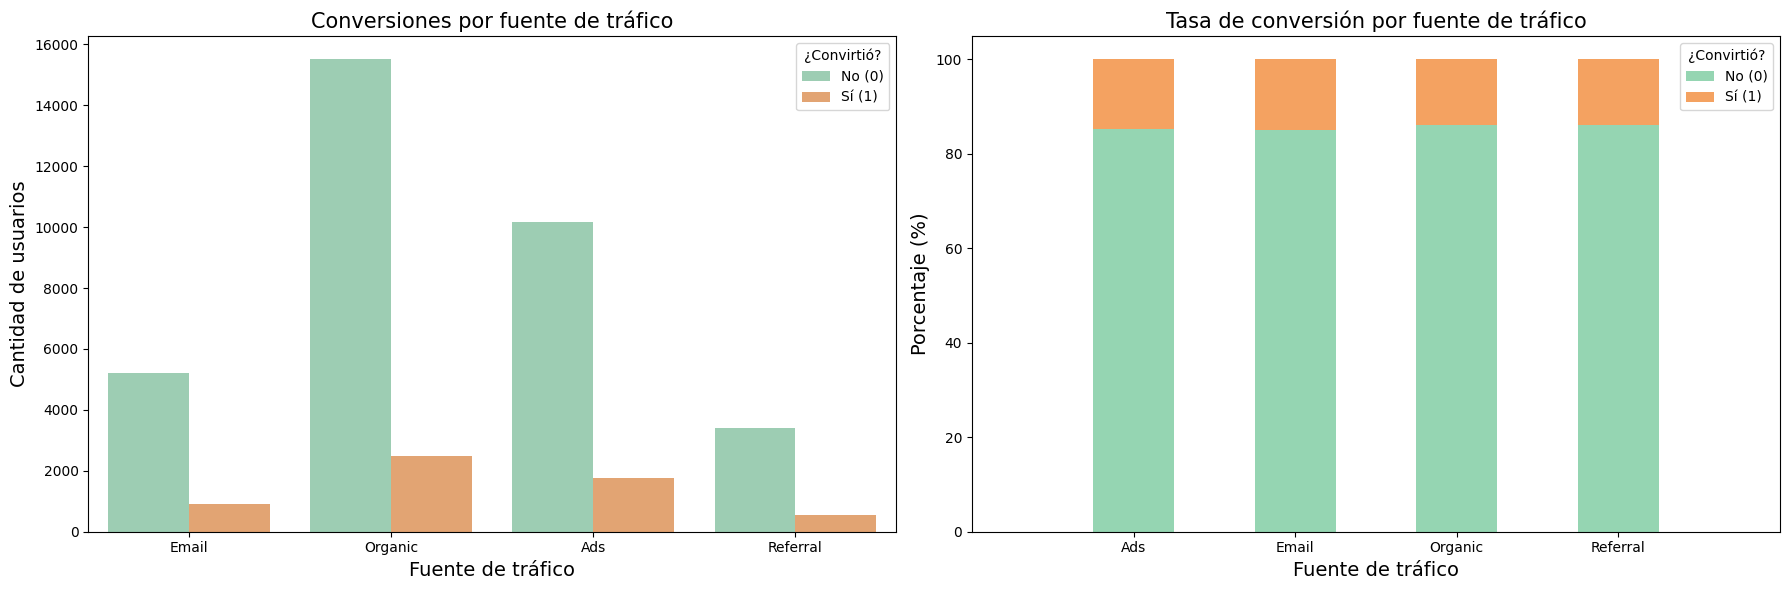

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras agrupadas
# -----------------------------
sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"], ax=axes[0])

axes[0].set_title('Conversiones por fuente de tráfico', fontsize=15)
axes[0].set_xlabel('Fuente de tráfico', fontsize=14)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=14)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Barras apiladas
# -----------------------------
tabla_normalizada_traffic.plot(kind='bar', stacked=True, color=["#95D5B2", "#F4A261"], ax=axes[1])

axes[1].set_title('Tasa de conversión por fuente de tráfico', fontsize=15)
axes[1].set_xlabel('Fuente de tráfico', fontsize=14)
axes[1].set_ylabel('Porcentaje (%)', fontsize=14)
axes[1].set_xlim(-1, 4)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Hallazgos:**

- Se visualiza que Email tiene conversión en 918 usuarios con una tasa del 14.99% Esta es la tasa más alta, es la fuente más efectiva para conversión.
- Se visualiza que Organic tiene alta cantidad de usuarios, pero solo 2480 usuarios convierten, con una tasa de conversión del 13.78%
- En el gráfico de porcentajes se visualizan tasas de conversión muy similares, aproximadamente del 14%
- Las diferencias entre las tasas de conversión son relativamente pequeñas (1% a 2%)

### Relación entre el tipo de usuario y la conversión

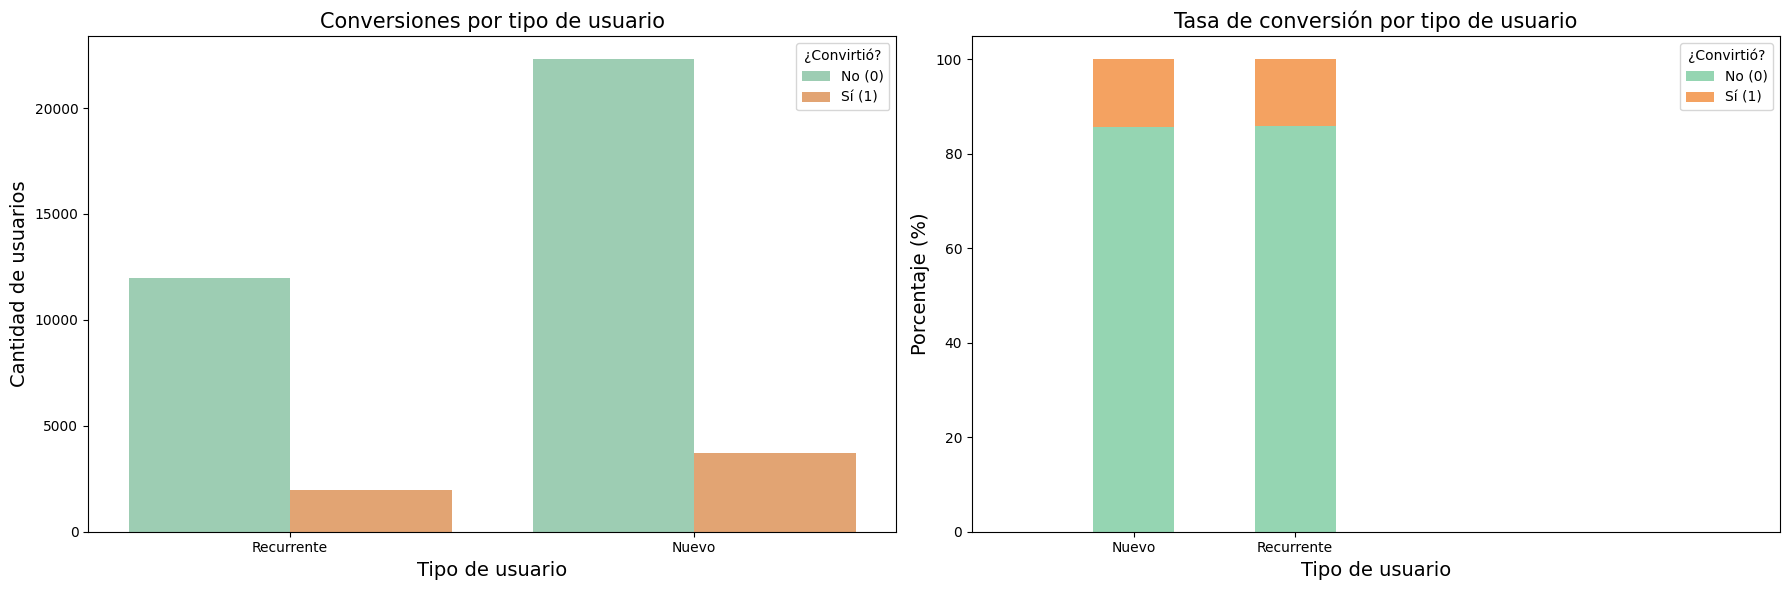

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras agrupadas
# -----------------------------
sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"], ax=axes[0])

axes[0].set_title('Conversiones por tipo de usuario', fontsize=15)
axes[0].set_xlabel('Tipo de usuario', fontsize=14)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=14)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Barras apiladas
# -----------------------------
tabla_normalizada_user.plot(kind='bar', stacked=True, color=["#95D5B2", "#F4A261"], ax=axes[1])

axes[1].set_title('Tasa de conversión por tipo de usuario', fontsize=15)
axes[1].set_xlabel('Tipo de usuario', fontsize=14)
axes[1].set_ylabel('Porcentaje (%)', fontsize=14)
axes[1].set_xlim(-1, 4)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Hallazgos:**
- Las proporciones de conversión son similares, aproximadamente 14%
- El tipo de usuario nuevo convirtió 14.35% y el recurrente 14.09%
- El tipo de usuario nuevo convierte ligeramente un poco más que el recurrente, 0.26% más.
- Una solo estrategia de marketing sirve para ambos segmentos.
- Aunque hay mucha más cantidad de usuarios nuevos, las tasas de conversión son muy similares
- Hay oportunidad de mejora, se deben implementar estrategias para que el tipo de usuario nuevo convierta en más ocasiones.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

## 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

Promedio de gasto A:
 61.0865724522293

Promedio de gasto B:
 68.74536005009392

Cantidad de datos de cada grupo
(A 2512, B 3194)

- **Interpretación:**

Hay evidencia de que la diferencia no es fruto del azar, el resultado es estadísticamente significativo.
Con base en la prueba t aplicada a los 2 grupos de usuarios, se encontró evidencia estadística de una diferencia en el gasto promedio entre las versiones de las páginas A y B.
En promedio, los usuarios que convirtieron en la página B gastaron más que los de la página A.
Este resultado se basa en 2 grupos de usuarios que realizaron compras y no evalúa si la diferencia observada es suficiente para justificar un cambio desde una perspectiva de negocio.

**Tasa de conversión:**

Usuarios convertidos por página:
 landing
A    2512
B    3194

Total de usuarios por página:
 landing
A    19982
B    20018

- **Interpretación:**

Con base en un z-test para proporciones, se encontró evidencia estadística de que la tasa de conversión difiere entre la página A y la página B.
La tasa de conversión de la página A es 12.57%
La tasa de conversión de la página B es 15.96%
La tasa de conversión de la página B es mayor 3.38% que la página A.
Este resultado sugiere que la página B tiene mayor conversión que la página A.


#### 📊 **Segmentación por fuente de tráfico**

Hay evidencia de asociación entre las variable fuente de tráfico y conversión.

Proporción de conversión por traffic source
converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163

- **Interpretación:**

- La mayor tasa se visualiza en Email con 918 conversiones y proporción de 14.99% Sugiere ser la fuente más efectiva para conversión.
- Ads 1759 conversiones (14.73%)
- Referral 549 conversiones (13.88%)
- Organic 2480 conversiones (13.78%)
- Las diferencias, aunque estadísticamente significativas, son relativamente pequeñas (1% a 2%)
- Se podría segmentar la inversión de marketing por tipo de tráfico, dado que se evidencia diferencias significativas.
- Enfocar esfuerzos en optimizar el email marketing (canal mas efectivo).
- Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

![image.png](attachment:540fcb87-632b-45c2-8bc7-16eb87b3624c.png)


#### 📊 **Segmentación por tipo de usuario**

- Proporción de conversión por tipo de usuario
converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356
  
- **Interpretación:**

- El tipo de usuario nuevo convierte 14.35%
- El tipo de usuario recurrente convierte 14.09%
- Las proporciones de conversión son muy similares.
- El tipo de usuario nuevo convierte ligeramente un poco más que el recurrente (0.26%), la diferencia es mínima en términos de negocio.
- Esto sugiere que no se debería segmentar la inversión según el tipo de usuario. Una sola estrategia de marketing sirve para ambos segmentos.

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

![image.png](attachment:16388e33-e041-43a4-b0b3-9d2ff9ed375a.png)

#### 💡 **Recomendaciones de negocio:**
**Fuente de tráfico**

- Maximizar Email Marketing, dar prioridad, dado que tiene la mayor tasa de conversión (14.99%)
- Email tiene un volumen moderado de 5205 usuarios, hay oportunidad de crecimiento potencial de ventas. Posible ROI potencial alto.
- Aumentar frecuencia de campañas de email.
- Segmentar listas de comportamiento.
- Implementar email automation.
- La fuente de tráfico Organic tiene el mayor volumen de usuarios. Crear contenido que convierta mejor. Optimizar páginas de aterrizaje para búsquedas específicas.

**Tipo de usuario**

- Mantener una sola estrategia de conversión.
- Enfocar recursos en optimizaciones que impacten a todos los usuarios.
- Aprovechar el volumen de usuarios nuevos (prioridad alta). Representan el 65% del tráfico total.
- Hay mayor oportunidad de crecimiento en los usuarios nuevos.
- Invertir más en adquisición de usuarios nuevos
- Optimizar el onboarding para primera visita.
- Crear programas de fidelización.
- Retargeting para usuarios que no convirtieron.